In [1]:
import torch; print("CUDA:", torch.cuda.is_available())
!nvidia-smi


CUDA: True
Mon Dec  1 14:32:20 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   46C    P8             13W /   70W |       2MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+------------------------------------

In [2]:
!pip install -q transformers==4.46.3 wordfreq scikit-learn matplotlib einops sentencepiece tokenizers typing_extensions
!rm -rf Tokens2Words
!git clone https://github.com/schwartz-lab-NLP/Tokens2Words.git
%cd Tokens2Words



Cloning into 'Tokens2Words'...
remote: Enumerating objects: 269, done.
remote: Counting objects: 100% (269/269), done.
remote: Compressing objects: 100% (156/156), done.
remote: Total 269 (delta 134), reused 212 (delta 84), pack-reused 0 (from 0)
Receiving objects: 100% (269/269), 179.13 KiB | 16.28 MiB/s, done.
Resolving deltas: 100% (134/134), done.
/content/Tokens2Words


In [3]:
import torch, transformers
print("CUDA:", torch.cuda.is_available(), "| torch", torch.__version__)


CUDA: True | torch 2.9.0+cu126


In [4]:
from wordfreq import top_n_list
from transformers import AutoTokenizer
from pathlib import Path

MODEL_NAME = "facebook/opt-1.3b"
tok = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=False)
words = top_n_list("en", 5000)
multi_60 = [w for w in words if len(tok.tokenize(w)) > 1][:60]

Path("word_lists").mkdir(exist_ok=True)
Path("word_lists/multitoken_60.txt").write_text("\n".join(multi_60))


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


404

In [5]:
print("Tokenizer loaded:", type(tok))
print("Number of multi-token words:", len(multi_60))

!ls -l word_lists
!head -n 5 word_lists/multitoken_60.txt

Tokenizer loaded: <class 'transformers.models.gpt2.tokenization_gpt2.GPT2Tokenizer'>
Number of multi-token words: 60
total 120
-rw-r--r-- 1 root root   404 Dec  1 14:32 multitoken_60.txt
-rwxr-xr-x 1 root root 59122 Dec  1 14:32 top_5k_arabic_words.txt
-rw-r--r-- 1 root root 53523 Dec  1 14:32 top_5k_hebrew_words_without_nikud.txt
it's
don't
i'm
you're
that's


In [6]:
%cd /content/Tokens2Words/src
!python -m tokens2words.run_patchscopes \
  --exp_name opt13b_multitok_60 \
  --model_name facebook/opt-1.3b \
  --seed 42 \
  --words_list ../word_lists/multitoken_60.txt \
  --patchscopes_prompt "English: X, X"


/content/Tokens2Words/src
2025-12-01 14:33:21.729991: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1764599601.848197   17041 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1764599601.856521   17041 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1764599601.885900   17041 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1764599601.885925   17041 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1764599601.885930   17041 computation_placer.cc:1

In [7]:
%cd /content/Tokens2Words/src
!ls -l experiments/opt13b_multitok_60 | head


/content/Tokens2Words/src
total 108
-rw-r--r-- 1 root root   617 Dec  1 14:35 config.json
-rw-r--r-- 1 root root 53482 Dec  1 14:35 patchscopes_results.csv
-rw-r--r-- 1 root root 47965 Dec  1 14:35 patchscopes_results.parquet


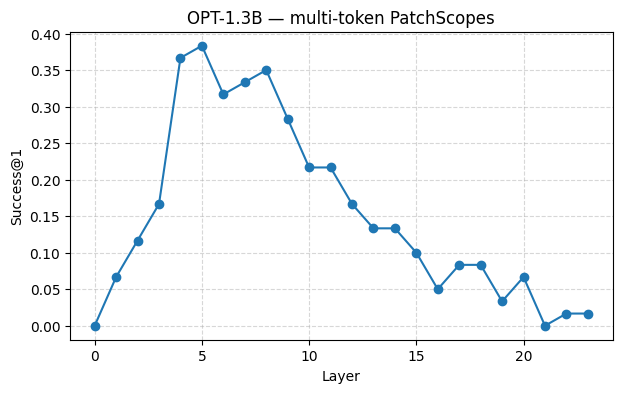

Peak Success@1 = 0.383 at layer 5
Saved CSV to: experiments/opt13b_multitok_60/results_layers.csv
Saved PNG to: experiments/opt13b_multitok_60/opt1-3b_multitok_success.png


In [8]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, pathlib

exp = "opt13b_multitok_60"
df  = pd.read_csv(f"experiments/{exp}/patchscopes_results.csv")

layers = df.iloc[:, 0].astype(int).to_numpy()
data   = df.drop(columns=df.columns[0])

succ1 = data.apply(
    lambda row: sum(isinstance(v,str) and k.lower() in v.lower() for k,v in row.items())/len(row),
    axis=1
).to_numpy()

peak_idx   = int(np.argmax(succ1))
peak_layer = int(layers[peak_idx])
peak_val   = float(succ1[peak_idx])

out_dir = pathlib.Path(f"experiments/{exp}")
out_dir.mkdir(parents=True, exist_ok=True)

(pd.DataFrame({"layer": layers, "success_at1": succ1})
   .to_csv(out_dir / "results_layers.csv", index=False))

png_path = out_dir / "opt1-3b_multitok_success.png"
plt.figure(figsize=(7,4))

plt.plot(layers, succ1, marker="o")
plt.xlabel("Layer"); plt.ylabel("Success@1")
plt.title("OPT-1.3B — multi-token PatchScopes")
plt.grid(True, ls="--", alpha=.5)
plt.savefig(png_path, dpi=160, bbox_inches="tight")
plt.show()

print(f"Peak Success@1 = {peak_val:.3f} at layer {peak_layer}")
print("Saved CSV to:", out_dir / "results_layers.csv")
print("Saved PNG to:", png_path)


In [9]:
# !pip -q install wordfreq

from wordfreq import top_n_list
from transformers import AutoTokenizer
from pathlib import Path

MODEL = "openlm-research/open_llama_3b"
tok = AutoTokenizer.from_pretrained(MODEL, use_fast=False)

words = top_n_list("en", 5000)
multi = [w for w in words if len(tok.tokenize(w)) > 1][:60]
Path("/content/Tokens2Words/word_lists").mkdir(exist_ok=True)
Path("/content/Tokens2Words/word_lists/multitoken_60_llama.txt").write_text("\n".join(multi))


You are using the default legacy behaviour of the <class 'transformers.models.llama.tokenization_llama.LlamaTokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565 - if you loaded a llama tokenizer from a GGUF file you can ignore this message


363

In [10]:
%cd /content/Tokens2Words/src
!python -m tokens2words.run_patchscopes \
  --exp_name openllama3b_multitok_60 \
  --model_name openlm-research/open_llama_3b \
  --seed 42 \
  --words_list ../word_lists/multitoken_60_llama.txt \
  --patchscopes_prompt "English: X, X"


/content/Tokens2Words/src
2025-12-01 14:39:46.621525: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1764599986.653928   18674 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1764599986.664000   18674 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1764599986.687980   18674 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1764599986.688013   18674 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1764599986.688021   18674 computation_placer.cc:1

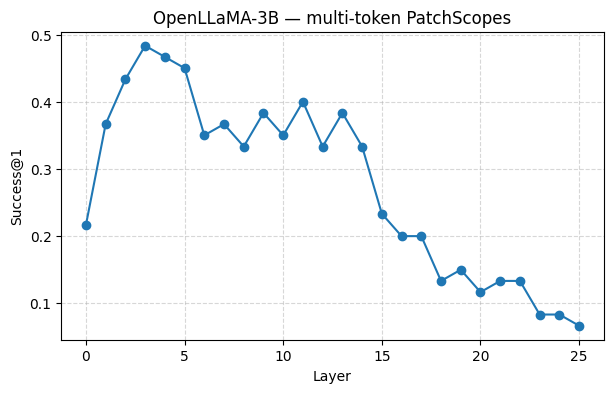

Peak Success@1 = 0.483 at layer 3
Saved CSV/PNG in: /content/Tokens2Words/src/experiments/openllama3b_multitok_60


In [11]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, pathlib

exp = "openllama3b_multitok_60"
csv = f"/content/Tokens2Words/src/experiments/{exp}/patchscopes_results.csv"

df = pd.read_csv(csv)
layers = df.iloc[:, 0].astype(int).to_numpy()
data   = df.drop(columns=df.columns[0])

succ1 = data.apply(
    lambda row: sum(isinstance(v, str) and k.lower() in v.lower() for k,v in row.items())/len(row),
    axis=1
).to_numpy()

peak_idx = int(np.argmax(succ1))
peak_val = float(succ1[peak_idx]); peak_layer = int(layers[peak_idx])

out_dir = pathlib.Path(f"/content/Tokens2Words/src/experiments/{exp}")
(out_dir / "results_layers.csv").write_text(
    pd.DataFrame({"layer": layers, "success_at1": succ1}).to_csv(index=False)
)

plt.figure(figsize=(7,4))
plt.plot(layers, succ1, marker="o")
plt.xlabel("Layer"); plt.ylabel("Success@1")
plt.title("OpenLLaMA-3B — multi-token PatchScopes")
plt.grid(True, ls="--", alpha=.5)
plt.savefig(out_dir / "openllama3b_multitok_success.png", dpi=160, bbox_inches="tight")
plt.show()

print(f"Peak Success@1 = {peak_val:.3f} at layer {peak_layer}")
print("Saved CSV/PNG in:", out_dir)


In [12]:
from google.colab import files
files.download("/content/Tokens2Words/src/experiments/openllama3b_multitok_60/results_layers.csv")
files.download("/content/Tokens2Words/src/experiments/openllama3b_multitok_60/openllama3b_multitok_success.png")
files.download("/content/Tokens2Words/src/experiments/openllama3b_multitok_60/patchscopes_results.csv")
files.download("/content/Tokens2Words/word_lists/multitoken_60_llama.txt")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [13]:
from google.colab import files
files.download("/content/Tokens2Words/src/experiments/opt13b_multitok_60/results_layers.csv")
files.download("/content/Tokens2Words/src/experiments/opt13b_multitok_60/opt1-3b_multitok_success.png")
files.download("/content/Tokens2Words/src/experiments/opt13b_multitok_60/patchscopes_results.csv")
files.download("/content/Tokens2Words/word_lists/multitoken_60.txt")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>